In [1]:
#importing therequired libraries for model Building and model evaluation

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

from surprise import Dataset, Reader, SVD, KNNBasic, accuracy
from surprise.model_selection import train_test_split, GridSearchCV
from surprise.prediction_algorithms.predictions import Prediction

ModuleNotFoundError: No module named 'surprise'

In [1]:
%pip install "scikit-surprise==1.1.3"

Defaulting to user installation because normal site-packages is not writeable
  Using cached scikit-surprise-1.1.3.tar.gz (771 kB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'error'
Note: you may need to restart the kernel to use updated packages.


  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> [50 lines of output]
      <string>:65: _DeprecatedInstaller: setuptools.installer and fetch_build_eggs are deprecated.
      !!
      
              ********************************************************************************
              Requirements should be satisfied by a PEP 517 installer.
              If you are using pip, you can try `pip install --use-pep517`.
      
              This deprecation is overdue, please update your project and remove deprecated
              calls to avoid build errors in the future.
              ********************************************************************************
      
      !!
      C:\Users\saumitra sundar rath\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe: No module named pip
      Traceback (most recent call last):
        File "C:\Users\saumit

In [3]:
conda install -n .conda ipykernel --update-deps --force-reinstall

ValueError: The python kernel does not appear to be a conda environment.  Please use ``%pip install`` instead.

In [8]:
%pip install scikit-surprise --user

  Using cached scikit_surprise-1.1.4.tar.gz (154 kB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'error'
Note: you may need to restart the kernel to use updated packages.


  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> [44 lines of output]
      Compiling surprise/similarities.pyx because it changed.
      Compiling surprise/prediction_algorithms/matrix_factorization.pyx because it changed.
      Compiling surprise/prediction_algorithms/optimize_baselines.pyx because it changed.
      Compiling surprise/prediction_algorithms/slope_one.pyx because it changed.
      Compiling surprise/prediction_algorithms/co_clustering.pyx because it changed.
      [1/5] Cythonizing surprise/prediction_algorithms/co_clustering.pyx
      
      Error compiling Cython file:
      ------------------------------------------------------------
      ...
              self.avg_cltr_i = avg_cltr_i
              self.avg_cocltr = avg_cocltr
      
              return self
      
          def compute_averages(self, np.ndarray[np.int_t] cltr_u,
                                                   ^
  

In [4]:
#Loading the Featured Engineering dataset
data = pd.read_csv('/content/Final_Model_Input_Data.csv')
df = pd.DataFrame(data)


FileNotFoundError: [Errno 2] No such file or directory: '/content/Final_Model_Input_Data.csv'

In [101]:
#Surprise dataset format

reader = Reader(rating_scale=(1, 10))
data = Dataset.load_from_df(
    df[["User-ID", "ISBN", "Book-Rating"]],
    reader
)

trainset, testset = train_test_split(data, test_size=0.2, random_state=42)

Hyperparameter Tuning using GridSearchCV

In [102]:
#Applying Hyperparameter tuning for SVD using GridsearchCV

param_grid = {
    "n_factors": [50, 100],
    "n_epochs": [20, 30],
    "lr_all": [0.002, 0.005],
    "reg_all": [0.02, 0.05]
}

print("\nRunning GridSearchCV for SVD...")

gs = GridSearchCV(SVD, param_grid, measures=["rmse"], cv=3)
gs.fit(data)

print("Best RMSE Score:", gs.best_score["rmse"])
print("Best Parameters:", gs.best_params["rmse"])

best_svd = SVD(**gs.best_params["rmse"])
best_svd.fit(trainset)

svd_predictions = best_svd.test(testset)


Running GridSearchCV for SVD...
Best RMSE Score: 1.6212821234509738
Best Parameters: {'n_factors': 50, 'n_epochs': 20, 'lr_all': 0.005, 'reg_all': 0.05}


Model Building i.e KNN (K nearest Neighbour)

In [103]:
# using KNN Model

sim_options = {"name": "cosine", "user_based": True}

knn_model = KNNBasic(k=40, sim_options=sim_options, verbose=False)
knn_model.fit(trainset)

knn_predictions = knn_model.test(testset)

In [104]:
#Hybrid model i.e SVD and KNN model Average

hybrid_predictions = []

for svd_pred, knn_pred in zip(svd_predictions, knn_predictions):
    hybrid_est = (svd_pred.est + knn_pred.est) / 2
    hybrid_predictions.append(
        Prediction(svd_pred.uid, svd_pred.iid, svd_pred.r_ui, hybrid_est, None)
    )



In [109]:

#Model Evaluation

print("\n========== MODEL EVALUATION ==========")

svd_rmse = accuracy.rmse(svd_predictions)
svd_mae = accuracy.mae(svd_predictions)

knn_rmse = accuracy.rmse(knn_predictions)
knn_mae = accuracy.mae(knn_predictions)

hybrid_rmse = accuracy.rmse(hybrid_predictions)
hybrid_mae = accuracy.mae(hybrid_predictions)

print("\nComparison Summary:")
print(f"SVD    -> RMSE: {svd_rmse:.4f}, MAE: {svd_mae:.4f}")
print(f"KNN    -> RMSE: {knn_rmse:.4f}, MAE: {knn_mae:.4f}")
print(f"Hybrid -> RMSE: {hybrid_rmse:.4f}, MAE: {hybrid_mae:.4f}")


========== MODEL EVALUATION ==========
RMSE: 1.6429
MAE:  1.3363
RMSE: 2.0193
MAE:  1.6223
RMSE: 1.7449
MAE:  1.4420

Comparison Summary:
SVD    -> RMSE: 1.6429, MAE: 1.3363
KNN    -> RMSE: 2.0193, MAE: 1.6223
Hybrid -> RMSE: 1.7449, MAE: 1.4420


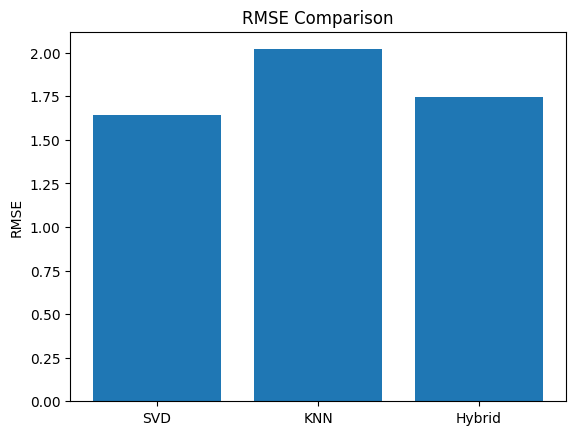

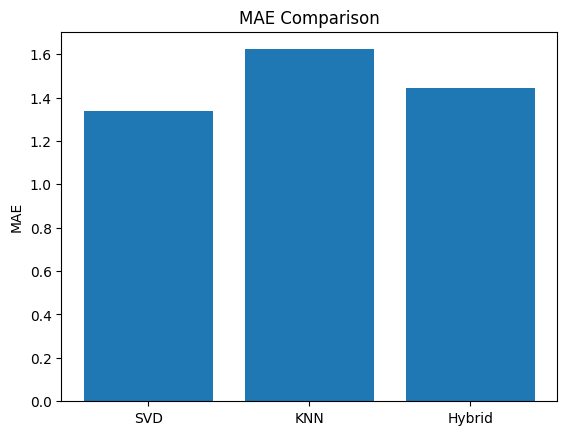

In [106]:

#Visualization of comparision of metrices with the 3 Models i.e SVD, KNN and Hybrid

models = ["SVD", "KNN", "Hybrid"]
rmse_values = [svd_rmse, knn_rmse, hybrid_rmse]
mae_values = [svd_mae, knn_mae, hybrid_mae]

# RMSE Plot
plt.figure()
plt.bar(models, rmse_values)
plt.title("RMSE Comparison")
plt.ylabel("RMSE")
plt.show()

# MAE Plot
plt.figure()
plt.bar(models, mae_values)
plt.title("MAE Comparison")
plt.ylabel("MAE")
plt.show()

In [107]:

#Precision and recall

def precision_recall_at_k(predictions, k=5, threshold=7):

    user_est_true = defaultdict(list)

    for uid, _, true_r, est, _ in predictions:
        user_est_true[uid].append((est, true_r))

    precisions = []
    recalls = []

    for uid, user_ratings in user_est_true.items():

        user_ratings.sort(key=lambda x: x[0], reverse=True)
        top_k = user_ratings[:k]

        n_rel = sum((true_r >= threshold) for (_, true_r) in user_ratings)
        n_rec_k = sum((est >= threshold) for (est, _) in top_k)
        n_rel_and_rec_k = sum(
            ((true_r >= threshold) and (est >= threshold))
            for (est, true_r) in top_k
        )

        precision = n_rel_and_rec_k / n_rec_k if n_rec_k != 0 else 0
        recall = n_rel_and_rec_k / n_rel if n_rel != 0 else 0

        precisions.append(precision)
        recalls.append(recall)

    return np.mean(precisions), np.mean(recalls)


precision, recall = precision_recall_at_k(hybrid_predictions, k=5)

print("\nPrecision@5:", round(precision, 4))
print("Recall@5:", round(recall, 4))



Precision@5: 0.7776
Recall@5: 0.7816


In [111]:

# Top 10 book recommendations based on best model selection

user_id = df["User-ID"].iloc[0]

all_books = df["ISBN"].unique()
rated_books = df[df["User-ID"] == user_id]["ISBN"].values

unrated_books = [book for book in all_books if book not in rated_books]

predictions = []

for book in unrated_books:
    pred = best_svd.predict(user_id, book)
    predictions.append((book, pred.est))

predictions.sort(key=lambda x: x[1], reverse=True)
top_10 = predictions[:10]

print("\nTop 10 Recommended Books for User:", user_id)

for isbn, rating in top_10:
    title = books[books["ISBN"] == isbn]["Book-Title"].values[0]
    print(title, "-> Predicted Rating:", round(rating, 2))


Top 10 Recommended Books for User: 3757
Harry Potter and the Sorcerer's Stone (Harry Potter (Paperback)) -> Predicted Rating: 8.39
Dreamcatcher -> Predicted Rating: 8.31
Harry Potter and the Order of the Phoenix (Book 5) -> Predicted Rating: 8.27
Lonesome Dove -> Predicted Rating: 8.25
The Secret Garden -> Predicted Rating: 8.24
Welcome to the World, Baby Girl! -> Predicted Rating: 8.24
Flirting with Pete : A Novel -> Predicted Rating: 8.22
Snow Falling on Cedars -> Predicted Rating: 8.21
The Handmaid's Tale : A Novel -> Predicted Rating: 8.21
Le Parfum : Histoire d'un meurtrier -> Predicted Rating: 8.21
